# Batch Normalization

To further improve the model, we'd like to normalize/standardize the data. With our pixel values following the srgb range of 0-255, we would like to avoid giving unfair representation to say the higher values in this scale rather than the values closer to zero. 
In a related example, imagine two feature that we'll pass in as inputs to a network, the first being yearly income, and the second being age.

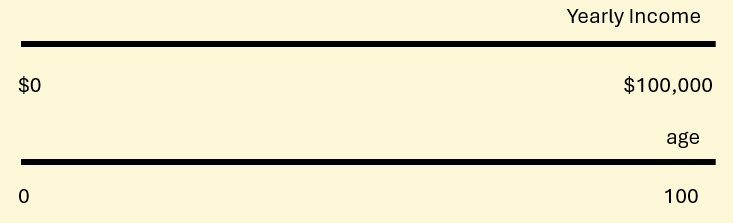  

If we appllied these filters without normalizing their range then we'd end up having the yearly income feature become disproportionately more **important** to the model then the age filter would ever become. To combat this, we normalize activation such that each feature has mean 0 and variance 1 during training. 
If we had a layer outptu $X$ with shape (batch size, height, width, channels) the steps are:
1. Compute mean and variance across the batch
  For channel $c$:   
$$
\mu _c = \frac{1}{N \cdot H \cdot W} \displaystyle \sum_{i=1}^{N} \sum_{h = 1}^{H} \sum_{w = 1}^{W} X_{i,h,w,c}  
$$
$$
\sigma ^2 _{c} = \frac{1}{N \cdot H \cdot W} \displaystyle \sum_{i=1}^{N} \sum_{h = 1}^{H} \sum_{w = 1}^{W} (X_{i,h,w,c} - \mu _c)^2 
$$
  where
  * N: batch size
  * H, W: spatial dimensions
  * c: channel index
2. Normalize activations

$$
\hat X_{i,h,w,c} = \frac {X_{i,h,w,c} - \mu _c}{\sqrt {\sigma ^2 _c + \epsilon}}
$$
  where:
  * $\epsilon$ is a small number (1e -5) to avoid division by zero. 

3. Scale and shift (optional learnable paramters): 
$$
Y_{i,h,w,c} = \gamma _c \hat X_{i, h, w, c} + \beta _c
$$
  where:
  * $ \gamma _c \text{ and } \beta _c $ are trainable paramters per channel. We can use these to undo normalization if necessary